In [38]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [39]:
x_train=x_train/255.0

In [40]:
x_test=x_test/255.0
x_test = x_test.reshape(-1, 28, 28, 1)

In [41]:
x_train = x_train.reshape(-1, 28, 28, 1)


In [42]:
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [43]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 32ms/step - accuracy: 0.9339 - loss: 0.2167 - val_accuracy: 0.9858 - val_loss: 0.0488
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9764 - loss: 0.0811 - val_accuracy: 0.9865 - val_loss: 0.0420
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 54s 32ms/step - accuracy: 0.9817 - loss: 0.0612 - val_accuracy: 0.9905 - val_loss: 0.0326
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 92s 38ms/step - accuracy: 0.9856 - loss: 0.0466 - val_accuracy: 0.9922 - val_loss: 0.0262
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9875 - loss: 0.0409 - val_accuracy: 0.9920 - val_loss: 0.0327


In [45]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9905 - loss: 0.0295
Test Accuracy: 0.9904999732971191


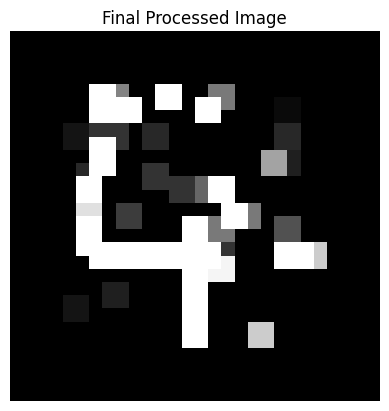

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Predicted Digit: 4
Confidence: 0.93157053


In [96]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread("digit1.png", cv2.IMREAD_GRAYSCALE)

img_blur = cv2.GaussianBlur(img, (5,5), 0)

thresh = cv2.adaptiveThreshold(
    img_blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11, 2
)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = max(contours, key=cv2.contourArea)

x, y, w, h = cv2.boundingRect(cnt)

padding = 10

size = max(w, h) + padding

cx = x + w // 2
cy = y + h // 2

x_start = max(cx - size//2, 0)
y_start = max(cy - size//2, 0)
x_end = min(cx + size//2, thresh.shape[1])
y_end = min(cy + size//2, thresh.shape[0])

digit = thresh[y_start:y_end, x_start:x_end]

digit = cv2.resize(digit, (20,20))

kernel = np.ones((2,2), np.uint8)
digit = cv2.dilate(digit, kernel, iterations=1)

final_img = np.zeros((28,28))
final_img[4:24, 4:24] = digit

final_img = final_img / 255.0

plt.imshow(final_img, cmap='gray')
plt.title("Final Processed Image")
plt.axis('off')
plt.show()

img_input = final_img.reshape(1,28,28,1)

prediction = model.predict(img_input)

predicted_digit = np.argmax(prediction)
confidence = np.max(prediction)

print("Predicted Digit:", predicted_digit)
print("Confidence:", confidence)

In [97]:
model.save("mnist_cnn_model.keras")